## Qiskit 2.x demo: Haar (length 8) as a Givens based wavelet transform
### and verification on y = (1, 0, -3, 2, 1, 0, 1, 2)

In [13]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
%matplotlib inline

# --- Helper: build the multi-level orthonormal Haar transform (N=2^m) ---

In [14]:
def haar_matrix(N: int) -> np.ndarray:
    """
    Orthonormal discrete Haar wavelet transform matrix (multilevel, Mallat ordering).
    Constructed as a product of 'pairwise averaging/differencing' (parallel Givens rotations)
    embedded at progressively smaller leading blocks.
    """
    assert N > 0 and (N & (N - 1) == 0), "N must be a power of two"
    W = np.eye(N)

    def level_block(n: int) -> np.ndarray:
        # Parallel 2x2 Haar rotations on pairs (0,1), (2,3), ... within an n-block
        H = np.zeros((n, n))
        c = 1 / np.sqrt(2)
        for k in range(n // 2):
            a, b = 2 * k, 2 * k + 1
            H[k, a] = c;  H[k, b] = c                        # averages
            H[n // 2 + k, a] = c; H[n // 2 + k, b] = -c      # differences
        return H

    n = N
    while n > 1:
        Hn = level_block(n)
        B = np.eye(N)
        B[:n, :n] = Hn
        W = B @ W
        n //= 2
    return W

# --- Input vector and expected transform (unnormalized) ---

In [15]:
y = np.array([1, 0, -3, 2, 1, 0, 1, 2], dtype=float)

expected = np.array([
    np.sqrt(2), -np.sqrt(2), 1.0, -1.0,
    1/np.sqrt(2), -5/np.sqrt(2), 1/np.sqrt(2), -1/np.sqrt(2)
], dtype=float)

# --- Build Haar unitary (8 x 8 real orthonormal) ---
N = 8
num_qubits = 3
W = haar_matrix(N)
# sanity: orthonormal
assert np.allclose(W.T @ W, np.eye(N), atol=1e-12)

# --- Prepare normalized state |y_norm> ---
norm_y = np.linalg.norm(y)
assert norm_y > 0
y_norm = y / norm_y

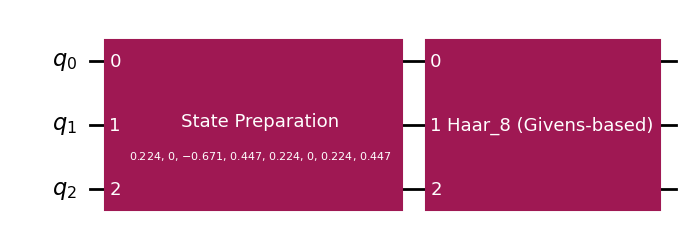

In [16]:
# --- Circuit: StatePreparation then Unitary(W) ---
qc = QuantumCircuit(num_qubits, name="Haar_Givens_Wavelet_8")
qc.append(StatePreparation(y_norm), qc.qubits)
qc.append(UnitaryGate(W, label="Haar_8 (Givens-based)"), qc.qubits)
# This uses matplotlib for nicer visuals inside Jupyter
qc.draw(output='mpl')
plt.savefig("ex07givens.png", dpi=300, bbox_inches="tight")
plt.savefig("ex07givens.pdf", dpi=300, bbox_inches="tight")

plt.show()  # <- show only after saving


# --- Exact simulation via Statevector (no Aer needed) ---
psi = Statevector.from_instruction(qc)   # |W y_norm>

In [17]:
# Recover unnormalized coefficients and remove global phase
Wy = np.asarray(psi.data) * norm_y
phase = np.exp(-1j * np.angle(Wy[0])) if np.abs(Wy[0]) > 1e-12 else 1.0
Wy = Wy * phase
Wy_real = np.real_if_close(Wy)

print("Computed Haar * y:\n", Wy_real)
print("\nExpected:\n", expected)

# Verify numerically
np.testing.assert_allclose(Wy_real, expected, atol=1e-9)
print("\n✅ Match confirmed.")

Computed Haar * y:
 [ 1.41421356 -1.41421356  1.         -1.          0.70710678 -3.53553391
  0.70710678 -0.70710678]

Expected:
 [ 1.41421356 -1.41421356  1.         -1.          0.70710678 -3.53553391
  0.70710678 -0.70710678]

✅ Match confirmed.
